In [1]:
import json
import os
import time
import warnings

import gc

import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import pysam
import pyfaidx
import pybedtools
import csv
import tensorflow as tf

from baskerville import seqnn
from baskerville import gene as bgene
from baskerville import dna

from borzoi_helpers import *

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2025-10-10 10:04:48.088952: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-10 10:04:48.089010: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-10 10:04:48.090090: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-10 10:04:48.096392: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-10 10:04:49.328025: W tensorflow/comp

In [ ]:
#Model configuration

params_file = 'saved_models_pbmc_multiome/params.json'
targets_file = 'saved_models_pbmc_multiome/targets_rna.txt' #Subset of targets.txt

seq_len = 524288
n_reps = 4       #To use only one model replicate, set to 'n_reps = 1'. To use all four replicates, set 'n_reps = 4'.
rc = True         #Average across reverse-complement prediction

#Read model parameters

with open(params_file) as params_open :
    
    params = json.load(params_open)
    
    params_model = params['model']
    params_train = params['train']

#Remove cropping
params_model['trunk'][-1]['cropping'] = 0

#Read targets

targets_df = pd.read_csv(targets_file, index_col=0, sep='\t')
target_index = targets_df.index

#Create local index of strand_pair (relative to sliced targets)
if rc :
    strand_pair = targets_df.strand_pair
    
    target_slice_dict = {ix : i for i, ix in enumerate(target_index.values.tolist())}
    slice_pair = np.array([
        target_slice_dict[ix] if ix in target_slice_dict else ix for ix in strand_pair.values.tolist()
    ], dtype='int32')

#Initialize model ensemble

models = []
for rep_ix in range(n_reps) :
    
    model_file = "saved_models_pbmc_multiome/f3c" + str(rep_ix) + "/train/model_best.h5"

    seqnn_model = seqnn.SeqNN(params_model)
    seqnn_model.restore(model_file, 0)
    seqnn_model.build_slice(target_index)
    if rc :
        seqnn_model.strand_pair.append(slice_pair)
    seqnn_model.build_ensemble(rc, [0])
    
    models.append(seqnn_model)


In [5]:
#Load genome fasta and gene annotations

#Initialize fasta sequence extractor
fasta_open = pysam.Fastafile('hg38/assembly/ucsc/hg38.fa')

#Load gene/exon annotation
gtf_file = 'hg38/genes/gencode41/gencode41_basic_nort.gtf'

transcriptome = bgene.Transcriptome(gtf_file)

#Get gene span bedtool
bedt_span = transcriptome.bedtool_span()

#Load APA atlas
apa_df = pd.read_csv('hg38/genes/polyadb/polyadb_human_v3.csv.gz', sep='\t', compression='gzip')
apa_df = apa_df[['pas_id', 'gene', 'chrom', 'position_hg38', 'strand', 'site_num', 'num_sites', 'site_type', 'pas_type', 'total_count']]

apa_df.loc[apa_df['pas_type'] == 'NoPAS', 'pas_type'] = 'No_CSE'

#Only consider 3' UTR sites
apa_df_utr = apa_df.query("site_type == '3\\' most exon'").copy().reset_index(drop=True)

#Or intronic sites
apa_df_intron = apa_df.query("site_type == 'Intron' and pas_type != 'No_CSE'").copy().reset_index(drop=True)

print("len(apa_df_utr) = " + str(len(apa_df_utr)))
print("len(apa_df_intron) = " + str(len(apa_df_intron)))

#Load TSS atlas
tss_df = pd.read_csv('hg38/genes/gencode41/gencode41_basic_tss2.bed', sep='\t', names=['chrom', 'position_hg38', 'end', 'tss_id', 'feat1', 'strand'])
tss_df['gene'] = tss_df['tss_id'].apply(lambda x: x.split("/")[1] if "/" in x else x)

print("len(tss_df) = " + str(len(tss_df)))


len(apa_df_utr) = 114605
len(apa_df_intron) = 83473
len(tss_df) = 116649


In [6]:
#Get stranded targets

def targets_prep_strand(targets_df) :
    
    #Attach strand
    targets_strand = []
    for _, target in targets_df.iterrows() :
        if target.strand_pair == target.name :
            targets_strand.append('.')
        else :
            targets_strand.append(target.identifier[-1])
    targets_df['strand'] = targets_strand

    #Collapse stranded
    strand_mask = (targets_df.strand != '-')
    targets_strand_df = targets_df[strand_mask]

    return targets_strand_df

targets_strand_df = targets_prep_strand(targets_df)


search_gene = ENSG00000066044


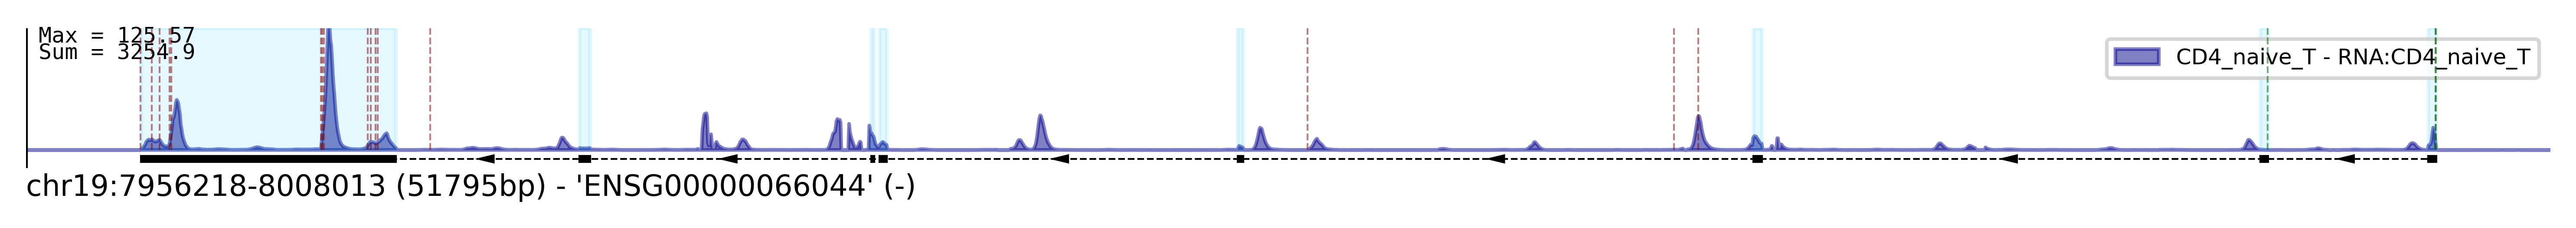

--- Measured ---


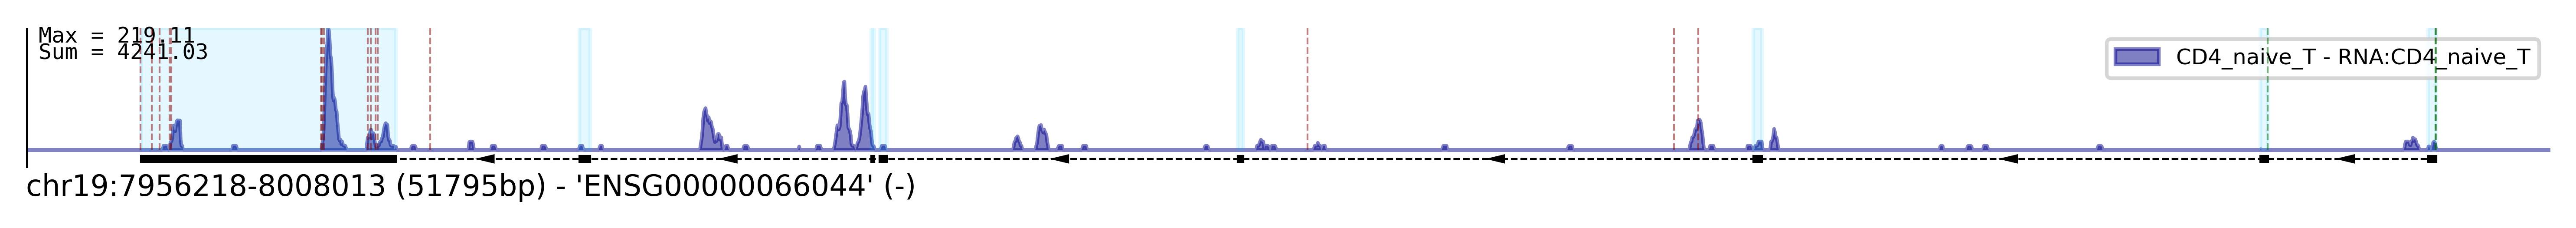

rp = [0.913]
rs = [0.691]
search_gene = ENSG00000095261


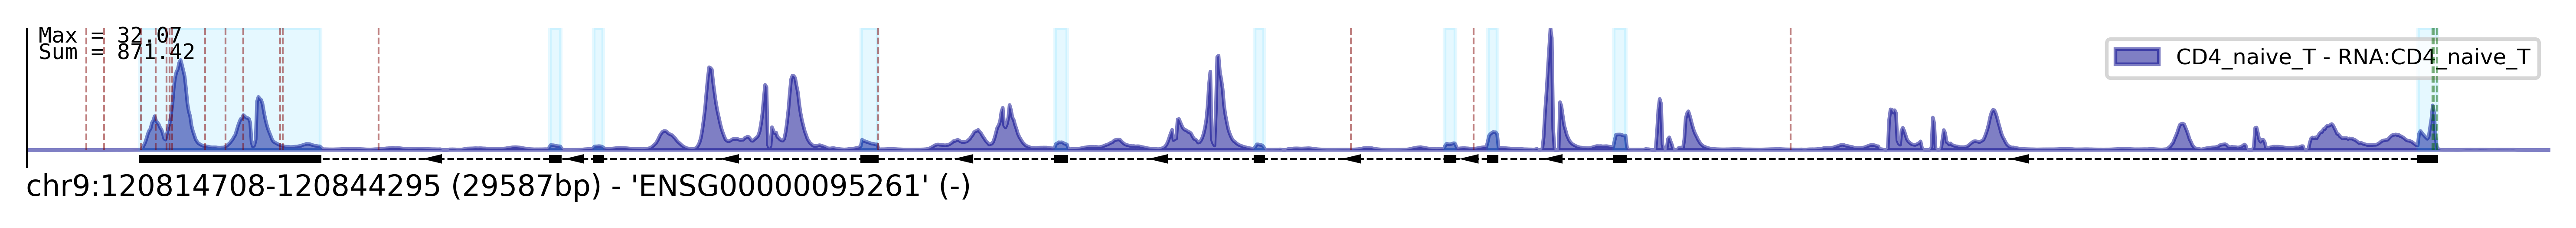

--- Measured ---


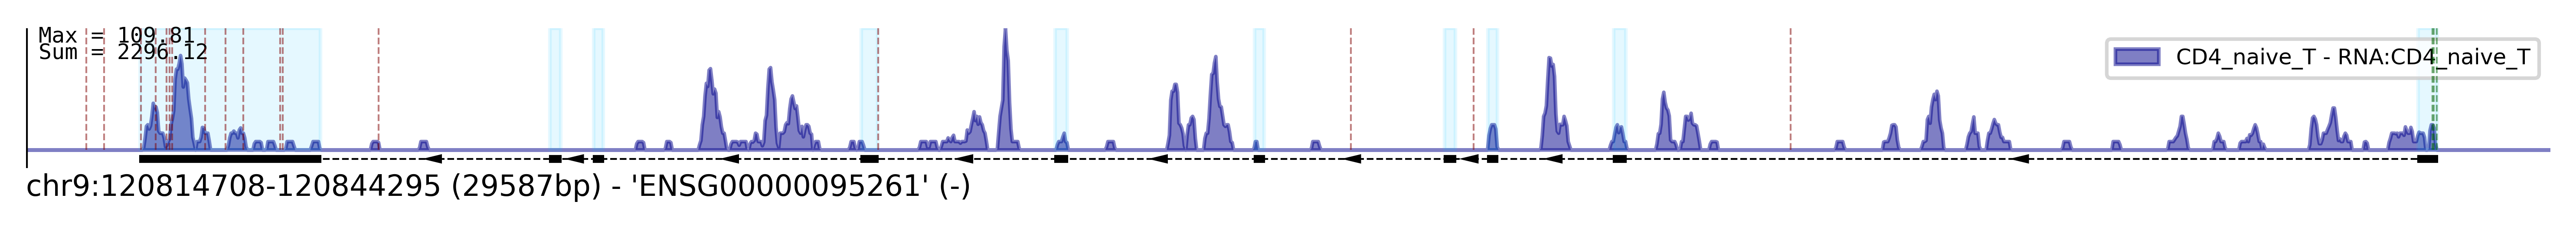

rp = [0.772]
rs = [0.648]
search_gene = ENSG00000165802


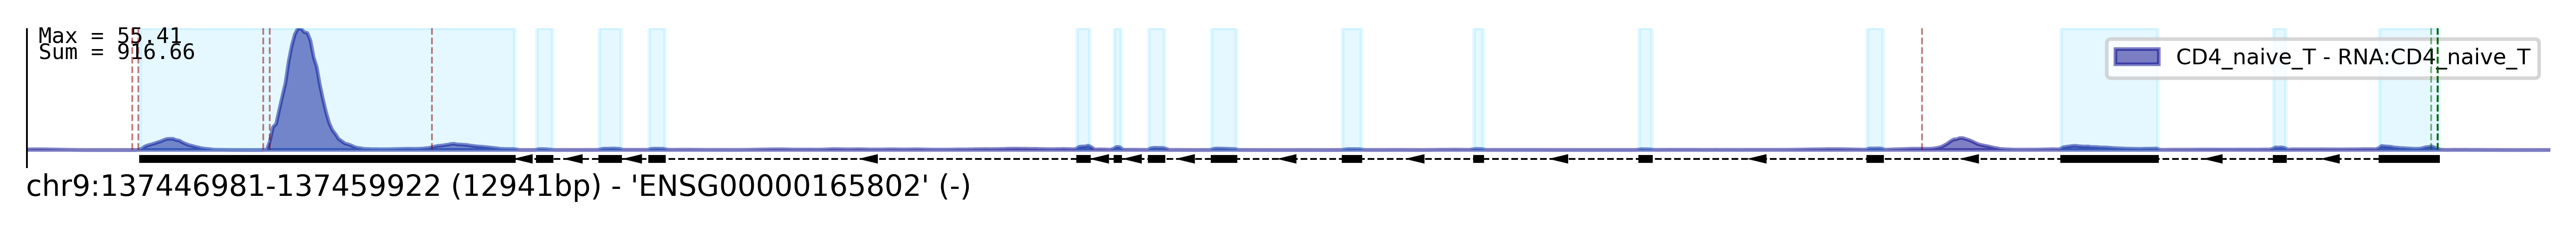

--- Measured ---


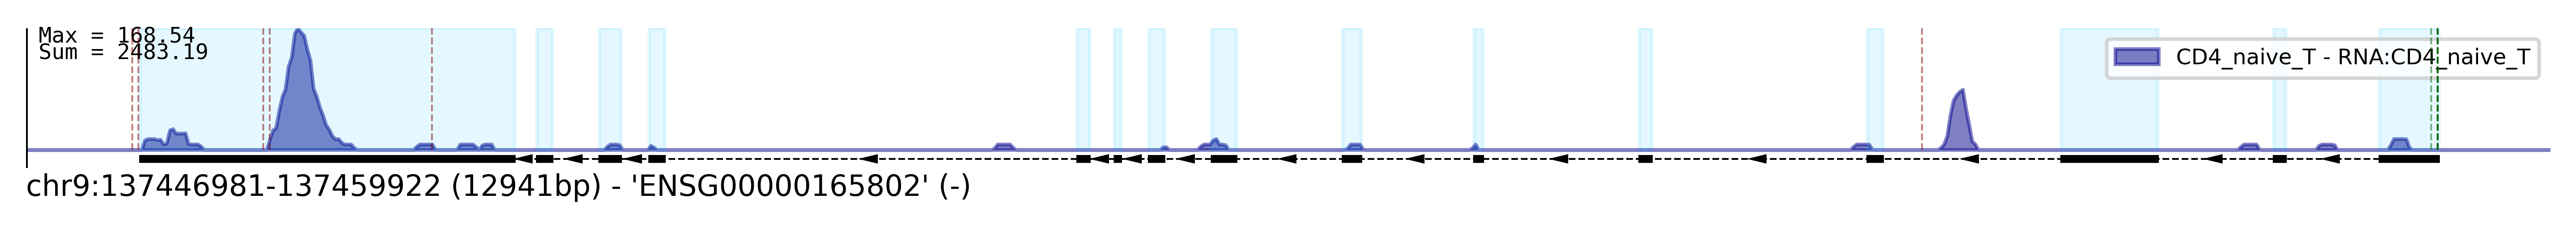

rp = [0.953]
rs = [0.594]
search_gene = ENSG00000132313


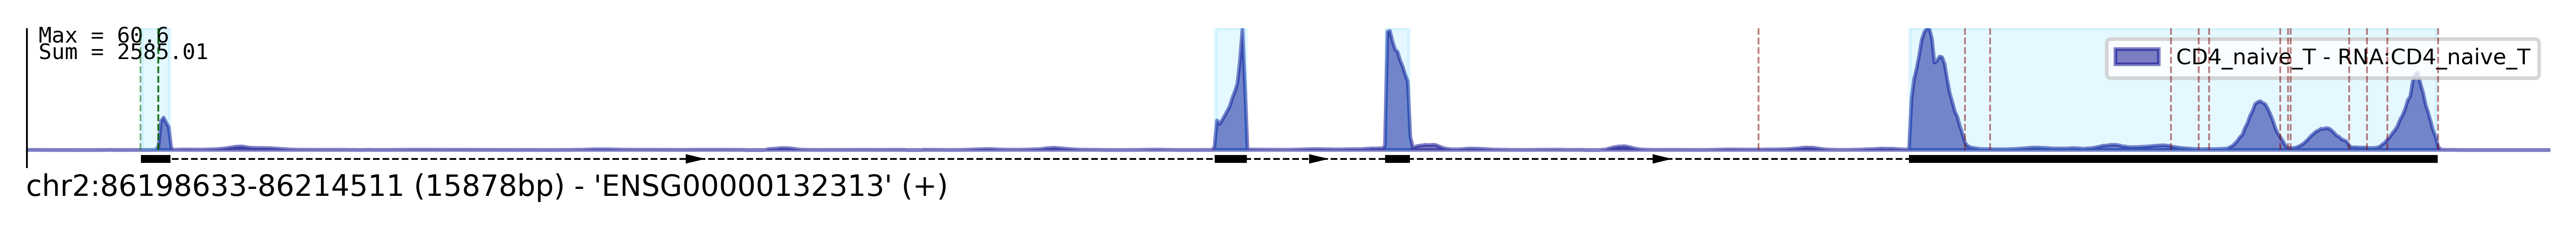

--- Measured ---


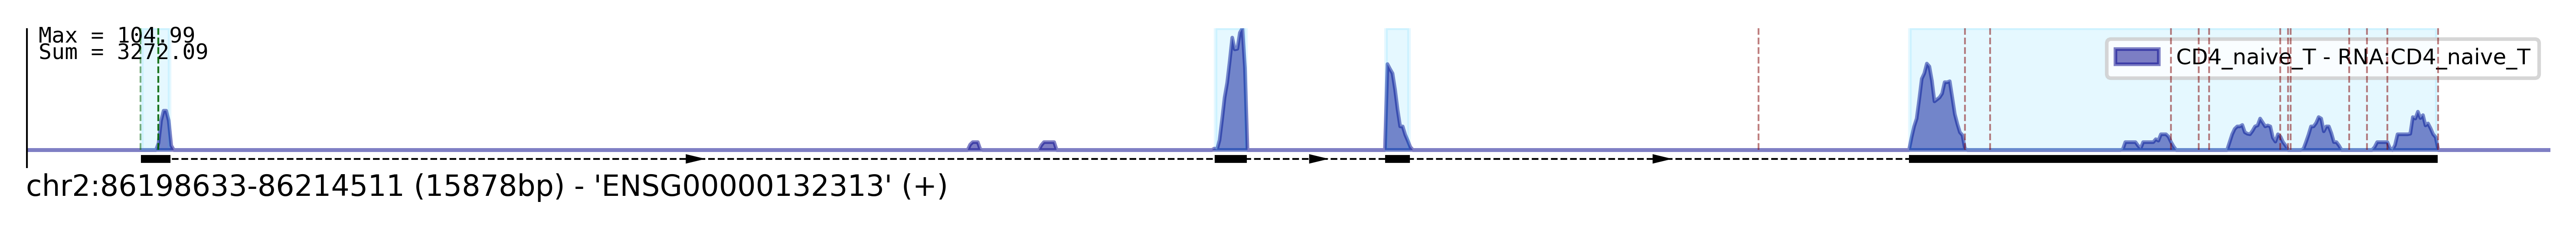

rp = [0.856]
rs = [0.882]
search_gene = ENSG00000139684


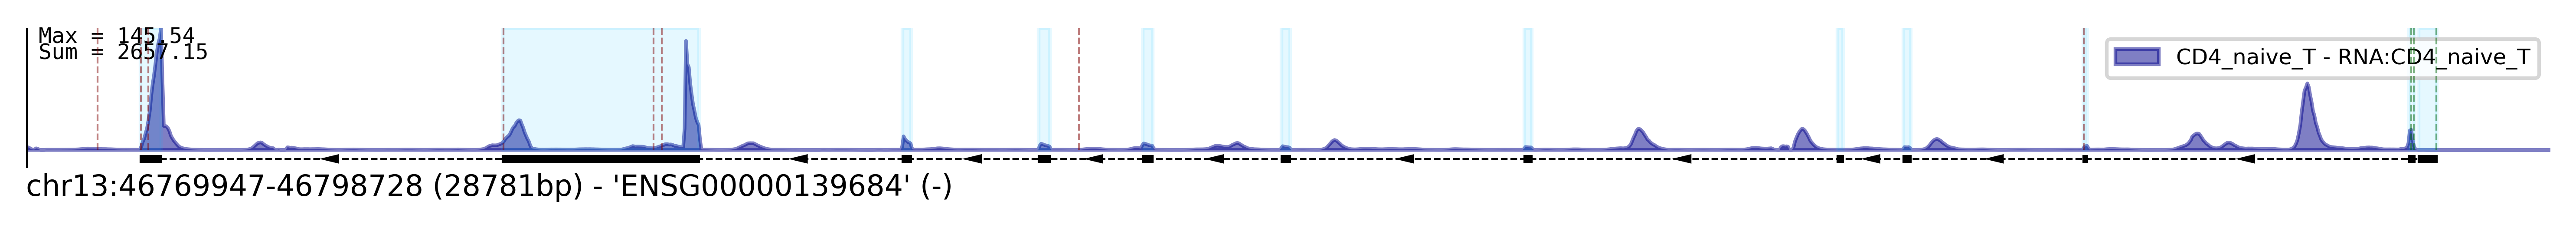

--- Measured ---


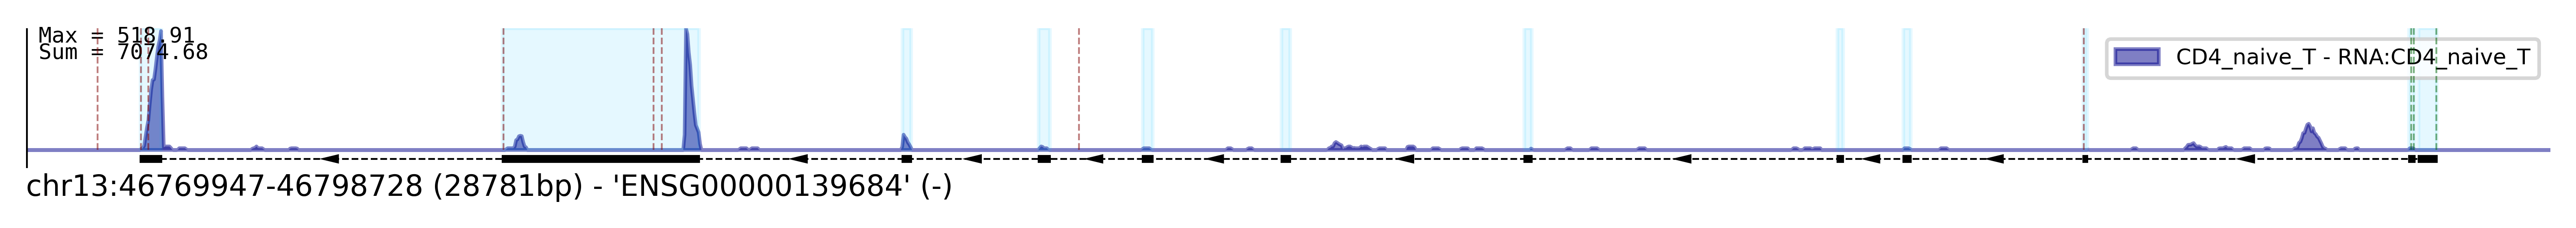

rp = [0.912]
rs = [0.775]


In [9]:
#Get reference/alternate sequence for variant, and annotations for target gene

search_genes = [
    'ENSG00000066044',
    'ENSG00000095261',
    'ENSG00000165802',
    'ENSG00000132313',
    'ENSG00000139684',
]

#Loop over genes to visualize
for search_gene in search_genes :

    print("search_gene = " + str(search_gene))
    
    chrom = None
    start = None
    end = None

    load_isoforms = True

    #Get exon bin range
    gene_keys = [gene_key for gene_key in transcriptome.genes.keys() if search_gene in gene_key]

    gene = transcriptome.genes[gene_keys[0]]
    gene_strand = gene.strand

    g_start, g_end = gene.span()
    gene_width = (g_end - g_start)

    #Calculate optimal plot width
    plot_width = 0
    if gene_width * 1.25 <= 4096 :
        plot_width = 4096
    elif gene_width * 1.25 <= 8192 :
        plot_width = 8192
    elif gene_width * 1.25 <= 16384 :
        plot_width = 16384
    elif gene_width * 1.25 <= 2*16384 :
        plot_width = 2*16384
    elif gene_width * 1.25 <= 4*16384 :
        plot_width = 4*16384
    elif gene_width * 1.25 <= 6*16384 :
        plot_width = 6*16384
    elif gene_width * 1.25 <= 8*16384 :
        plot_width = 8*16384
    elif gene_width * 1.25 <= 12*16384 :
        plot_width = 12*16384
    else :
        plot_width = 524288

    if chrom is None or start is None or end is None :
        chrom = gene.chrom
        mid = (g_start + g_end) // 2
        start = mid - 524288 // 2
        end = mid + 524288 // 2

    #Determine output sequence start
    seq_out_start = start + seqnn_model.model_strides[0]*seqnn_model.target_crops[0]
    seq_out_len = seqnn_model.model_strides[0]*seqnn_model.target_lengths[0]

    #Determine output positions of gene exons
    gene_slice = gene.output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True)

    #Get sequence bedtool
    seq_bedt = pybedtools.BedTool('%s %d %d' % (chrom, start, end), from_string=True)

    #Get all genes (exons and strands) overlapping input window
    gene_ids = sorted(list(set([overlap[3] for overlap in bedt_span.intersect(seq_bedt, wo=True) if search_gene not in overlap[3]])))
    gene_slices = []
    gene_strands = []
    for gene_id in gene_ids :
        gene_slices.append(transcriptome.genes[gene_id].output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True))
        gene_strands.append(transcriptome.genes[gene_id].strand)

    #Get 3' UTR pA sites for gene
    apa_df_gene_utr = apa_df_utr.query("gene == '" + gene.name + "'").copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]
    apa_df_gene_intron = apa_df_intron.query("gene == '" + gene.name + "'").copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]

    #Get TSS sites for gene
    tss_df_gene = tss_df.loc[tss_df['gene'].str.contains(search_gene)].copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]

    def _switch_transcript_id(id_str) :
        return id_str.replace("gene_id", "gene_id_orig").replace("transcript_id", "gene_id")

    #Get gene isoforms
    isoform_slices = None
    if load_isoforms :
        gtf_df = pd.read_csv(gtf_file, sep='\t', skiprows=5, names=['chrom', 'havana_str', 'feature', 'start', 'end', 'feat1', 'strand', 'feat2', 'id_str'])
        gtf_df = gtf_df.loc[gtf_df['id_str'].str.contains(search_gene)].copy().reset_index(drop=True)
        gtf_df = gtf_df.loc[gtf_df['id_str'].str.contains("transcript_id")].copy().reset_index(drop=True)
        gtf_df = gtf_df.loc[gtf_df['feature'] == 'exon'].copy().reset_index(drop=True)

        transcript_ids = gtf_df['id_str'].apply(lambda x: x.split("transcript_id \"")[1].split("\";")[0]).unique().tolist()
        gtf_df['id_str'] = gtf_df['id_str'].apply(_switch_transcript_id)

        gtf_df.to_csv('borzoi_gene_isoforms.gtf', sep='\t', index=False, header=False, quoting=csv.QUOTE_NONE)

        transcriptome_iso = bgene.Transcriptome('borzoi_gene_isoforms.gtf')

        isoform_slices = []
        for transcript_id in transcript_ids :
            isoform_slices.append(transcriptome_iso.genes[transcript_id].output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True))

    #Predict

    sequence_one_hot_wt = process_sequence(fasta_open, chrom, start, end)

    #Make predictions
    y_wt = predict_tracks(models, sequence_one_hot_wt)

    #Mask cropped prediction with zeros
    zero_pad = 10240

    if zero_pad > 0 :
        mask_mat = np.zeros(y_wt.shape, dtype=y_wt.dtype)
        mask_mat[:, :, zero_pad:-zero_pad, :] = 1.

        y_wt *= mask_mat

    #Plot

    save_figs = True
    save_suffix = '_' + search_gene

    #Visualize coverage tracks
    bin_size = 16
    pad = 0
    plot_start = g_start - start - int(0.05 * gene_width)
    plot_end = g_end - start + int(0.05 * gene_width)

    plot_measurements = True

    highlight_covr_poses_rel = None
    covr_orientation = 'before'
    covr_agg = 'mean'
    covr_width = 15

    #Tracks
    track_indices = [
        np.nonzero((targets_df['identifier'].str.contains('\\' + gene_strand) & targets_df['description'].str.contains('RNA:CD4_naive_T')).values)[0].tolist(),
    ]

    track_names = [
        'RNA:CD4_naive_T',
    ]

    track_files = [
        targets_df.loc[targets_df['identifier'].str.contains('\\' + gene_strand) & targets_df['description'].str.contains('RNA:CD4_naive_T')]['file'].values.tolist(),
    ]

    track_colors = [
        ['darkblue'],
    ]

    track_labels = [
        ['CD4_naive_T'],
    ]

    track_scale = 0.03
    track_transform = 1./2.
    soft_clip = None

    untransform_old = False

    #Plot coverage
    plot_coverage_tracks(
        y_wt,
        track_indices,
        track_names,
        track_colors,
        track_labels,
        track_scale,
        track_transform,
        soft_clip,
        start,
        log_scale=False,
        same_scale=True,
        plot_pair=False,
        plot_start_rel=plot_start,
        plot_end_rel=plot_end,
        highlight_covr_poses_rel=highlight_covr_poses_rel,
        covr_orientation=covr_orientation,
        covr_agg=covr_agg,
        covr_width=covr_width,
        bin_size=bin_size,
        pad=pad,
        save_figs=save_figs,
        save_suffix=save_suffix + '_pred',
        gene_slice=gene_slice,
        gene_slices=gene_slices,
        isoform_slices=isoform_slices,
        gene_strand=gene_strand,
        chrom=chrom,
        search_gene=search_gene,
        gene_strands=gene_strands,
        apa_df_gene_utr=apa_df_gene_utr,
        apa_df_gene_intron=apa_df_gene_intron,
        tss_df_gene=tss_df_gene,
        annotate_utr_apa=True,
        annotate_intron_apa=True,
        annotate_tss=True,
        plot_strands=True,
        plot_other_genes=False,
        plot_other_gene_strands=False,
        plot_isoforms=False,
        plot_isoform_strands=False,
        gene_color='black',
        isoform_color='dimgray',
        other_gene_color='black',
        max_isoforms=5,
        isoform_height_frac=0.,
        plot_as_bars=False,
        fig_size=(10, 1),
        untransform_old=untransform_old,
    )

    if plot_measurements :

        track_scale = 0.03
        track_transform = 1./2.
        soft_clip = None

        y_meas = []
        track_indices_meas = []

        track_i = 0
        for cov_files in track_files :

            file_scales = []
            for cov_file in cov_files :
                file_scales.append(
                    targets_df.loc[targets_df['file'] == cov_file]['scale'].iloc[0]
                )

            read_coverage_func, close_coverage_func = get_coverage_reader(cov_files, 32768, 0, "hg38/blacklist/blacklist_hg38_all.bed")
            cov_targets = read_coverage_func(chrom, start, end, clip_soft=384., clip=384., scale=track_scale, scales=None, transform_old=False)
            close_coverage_func()

            y_meas.append(cov_targets[None, None, ...])

            track_index = []
            for j in range(len(cov_files)) :
                track_index.append(track_i)
                track_i += 1

            track_indices_meas.append(track_index)

        y_meas = np.concatenate(y_meas, axis=-1)

        print("--- Measured ---")

        #Plot coverage
        plot_coverage_tracks(
            y_meas,
            track_indices_meas,
            track_names,
            track_colors,
            track_labels,
            track_scale,
            track_transform,
            soft_clip,
            start,
            log_scale=False,
            same_scale=True,
            plot_pair=False,
            plot_start_rel=plot_start,
            plot_end_rel=plot_end,
            highlight_covr_poses_rel=highlight_covr_poses_rel,
            covr_orientation=covr_orientation,
            covr_agg=covr_agg,
            covr_width=covr_width,
            bin_size=bin_size,
            pad=pad,
            save_figs=save_figs,
            save_suffix=save_suffix + '_meas',
            gene_slice=gene_slice,
            gene_slices=gene_slices,
            isoform_slices=isoform_slices,
            gene_strand=gene_strand,
            chrom=chrom,
            search_gene=search_gene,
            gene_strands=gene_strands,
            apa_df_gene_utr=apa_df_gene_utr,
            apa_df_gene_intron=apa_df_gene_intron,
            tss_df_gene=tss_df_gene,
            annotate_utr_apa=True,
            annotate_intron_apa=True,
            annotate_tss=True,
            plot_strands=True,
            plot_other_genes=False,
            plot_other_gene_strands=False,
            plot_isoforms=False,
            plot_isoform_strands=False,
            gene_color='black',
            isoform_color='dimgray',
            other_gene_color='black',
            max_isoforms=5,
            isoform_height_frac=0.,
            plot_as_bars=False,
            fig_size=(10, 1),
            untransform_old=untransform_old,
        )
    
    #Reduce to 32bp res
    y_wt = np.reshape(y_wt, (y_wt.shape[0], y_wt.shape[1], y_wt.shape[2] // 2, 2, y_wt.shape[3]))
    y_wt = np.mean(y_wt, axis=-2)
    
    y_meas = np.reshape(y_meas, (y_meas.shape[0], y_meas.shape[1], y_meas.shape[2] // 2, 2, y_meas.shape[3]))
    y_meas = np.mean(y_meas, axis=-2)
    
    #Undo sqrt
    y_wt = (y_wt + 1)**(1. / track_transform) - 1
    y_meas = (y_meas + 1)**(1. / track_transform) - 1

    #Extract log2-normalized exon bin coverages
    y_bin_hat = np.log2(y_wt[..., gene_slice // 2, :] + 1.)[..., track_indices][0, ..., 0]
    y_bin = np.log2(y_meas[..., gene_slice // 2, :] + 1.)[0, 0, ...]

    #Evaluate pearson and spearman bin-level correlations within exon bins
    from scipy.stats import pearsonr, spearmanr

    rp = [
        np.mean([pearsonr(y_bin_hat[i, :, j], y_bin[:, j])[0] for i in range(y_bin_hat.shape[0])])
        for j in range(y_bin_hat.shape[2])
    ]

    rs = [
        np.mean([spearmanr(y_bin_hat[i, :, j], y_bin[:, j])[0] for i in range(y_bin_hat.shape[0])])
        for j in range(y_bin_hat.shape[2])
    ]

    print("rp = " + str(np.round(rp, 3)))
    print("rs = " + str(np.round(rs, 3)))
